# Recinos PCA

## Import libraries

In [80]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD as SVD, PCA
import plotly_express as px

## Get the data

In [27]:
OHCO = ['parte', 'capit']
TFIDF = pd.read_csv("recinos-TFIDF.csv").set_index(OHCO)
DOC = pd.read_csv("recinos-DOC.csv").set_index(OHCO)
LABEL = pd.read_csv("recinos-LABEL.csv").set_index('label')
VOCAB = pd.read_csv("recinos-VOCAB.csv").set_index('term_str')

## Transform the data

In [81]:
# comp_engine = SVD(n_components=10)
comp_engine = PCA(n_components=10)
M = comp_engine.fit_transform(TFIDF)
DCM = pd.DataFrame(M, index=TFIDF.index)
DCM.columns = [f"PC{col}" for col in DCM.columns]

In [82]:
DCM.head()

PC0       PC1       PC2       PC3       PC4       PC5  \
parte capit                                                               
0     1      0.018386 -0.047076 -0.251035 -0.240871  0.066815 -0.124343   
1     1     -0.014948 -0.193779 -0.276522 -0.324011 -0.172014  0.011228   
      2     -0.021782 -0.225019 -0.220129 -0.424689 -0.175975  0.169144   
      3     -0.053493 -0.127331 -0.121542 -0.258824 -0.127189  0.293915   
      4     -0.050315 -0.359217 -0.292811  0.099416 -0.017188 -0.160167   

                  PC6       PC7       PC8       PC9  
parte capit                                          
0     1     -0.082315  0.070351  0.246500 -0.126541  
1     1     -0.060027 -0.006648  0.073386 -0.060416  
      2      0.054992 -0.067948 -0.090554 -0.019484  
      3      0.042501 -0.207847 -0.031097  0.091597  
      4      0.288283  0.231769 -0.156313  0.018073

# Cluster Docs by Components

In [83]:
import sys
sys.path.append("../../local_lib/")

In [84]:
from hac2 import HAC

In [85]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [86]:
fig1 = HAC(DCM)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [87]:
# fig1.color_thresh = 2.5 # w/o verbs
fig1.color_thresh = 2.4

<Figure size 640x480 with 0 Axes>

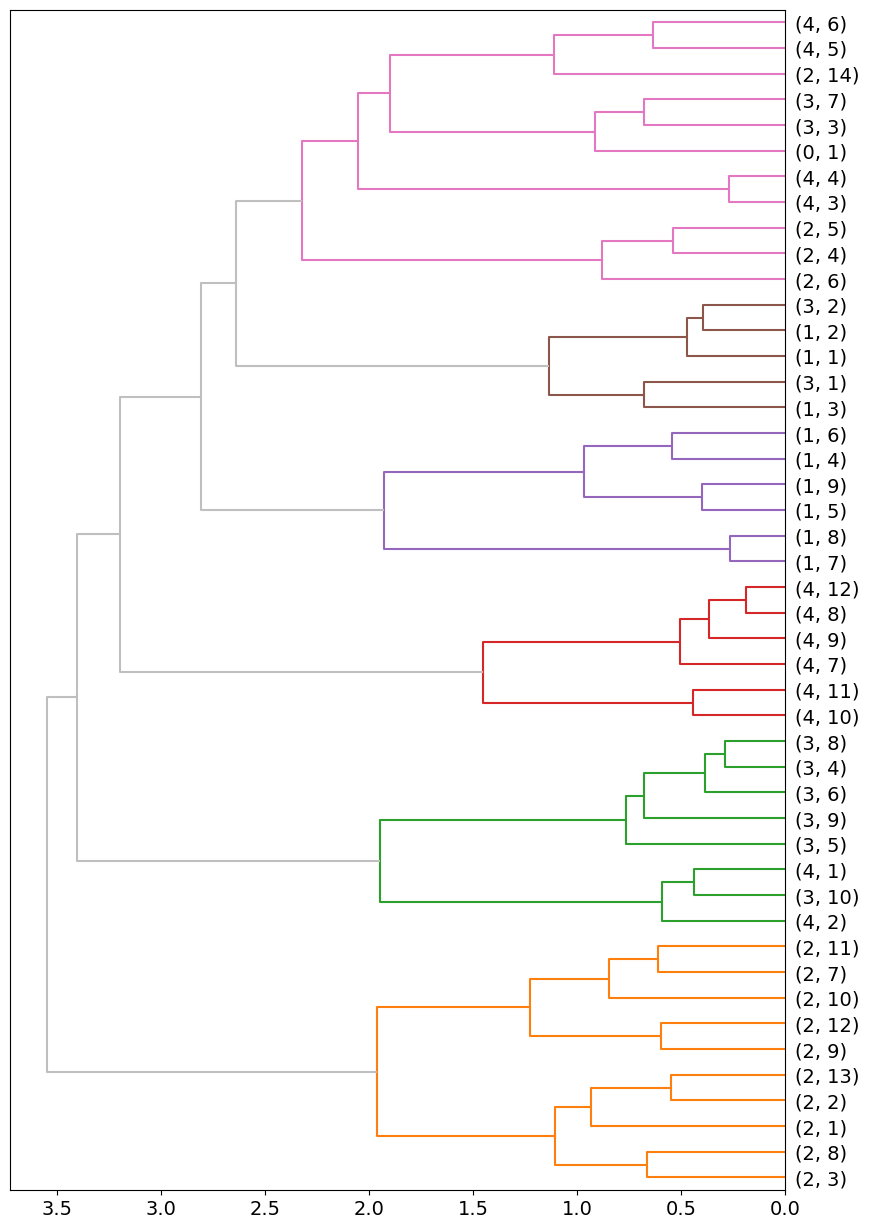

In [88]:
fig1.plot()

In [89]:
fig1.get_cluster_labels()
DOC['label_pca'] = fig1.CLUSTER_LABELS

In [90]:
label_color = {
    '1': 'orange',
    '2': 'limegreen',
    '3': 'red',
    '4': 'violet',
    '5': 'tan',
    '6': 'teal',
    '7': 'lightgray',
    '': 'white'
}

In [91]:
DOC.label_pca.unstack(fill_value='').style\
    .applymap(lambda x: 'background:' + label_color[str(x)])

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14
parte,,,,,,,,,,,,,,
0,6,,,,,,,,,,,,,
1,5,5,5,4,4,4,4,4,4,,,,,
2,1,1,1,6,6,6,1,1,1,1,1,1,1,6
3,5,5,6,2,2,2,6,2,2,2,,,,
4,2,2,6,6,6,6,3,3,3,3,3,3,,


## Visualize components

In [92]:
D = DCM.join(DOC).join(LABEL, on='label').reset_index()
D['chap_text'] = D.doc_str.str[:40]
D['chap_label'] = D.parte.astype(str) + ':' + D.capit.astype(str)

In [93]:
def plot_comps(x,y):
    return px.scatter(D, 
        f"PC{x}", f"PC{y}", 
        height=600, width=700, 
        color='gloss',
        hover_data='chap_text',
        hover_name='chap_label',
        marginal_x='box')

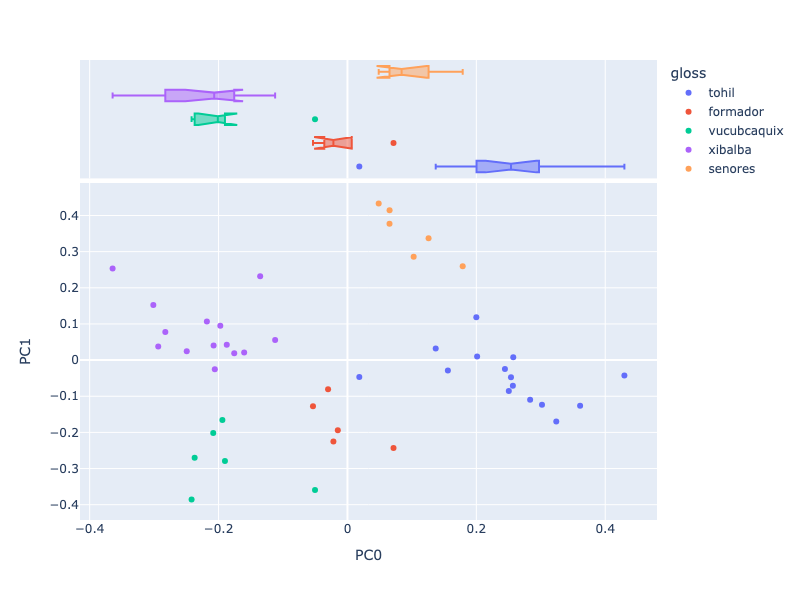

In [94]:
plot_comps(0,1)

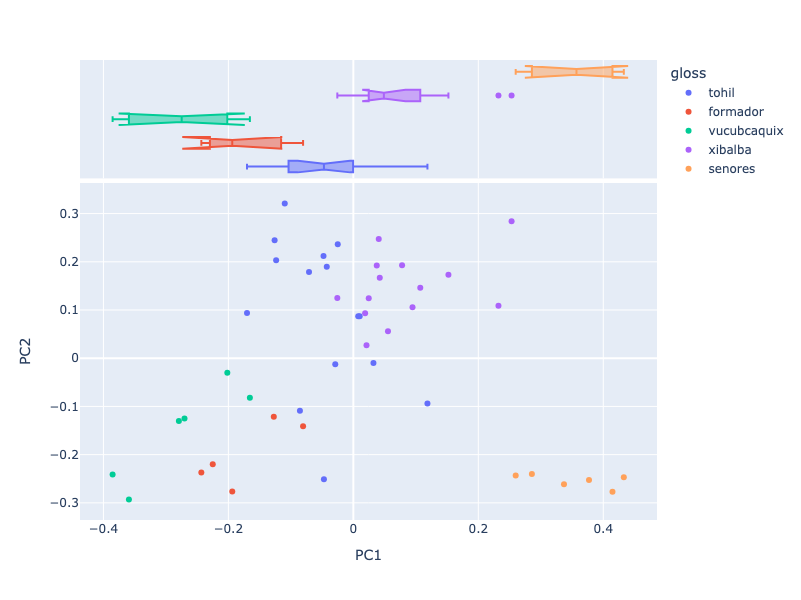

In [95]:
plot_comps(1,2)

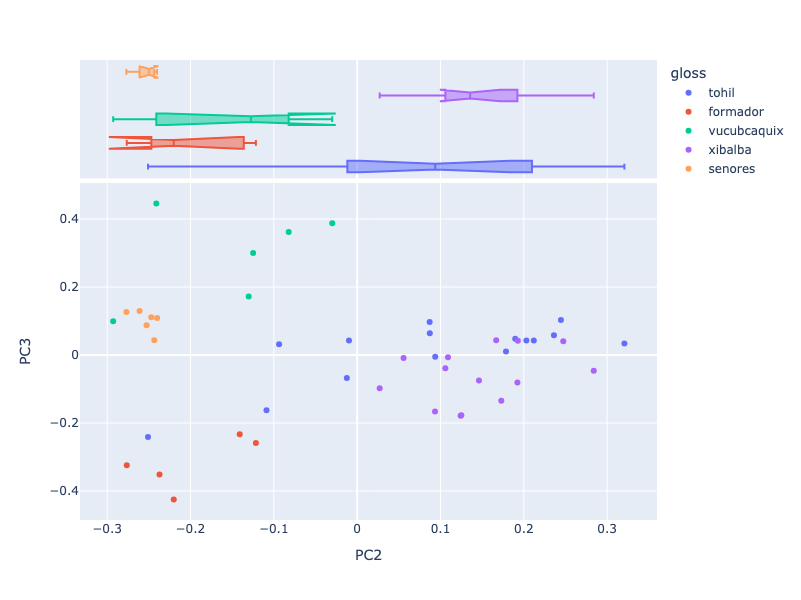

In [96]:
plot_comps(2,3)

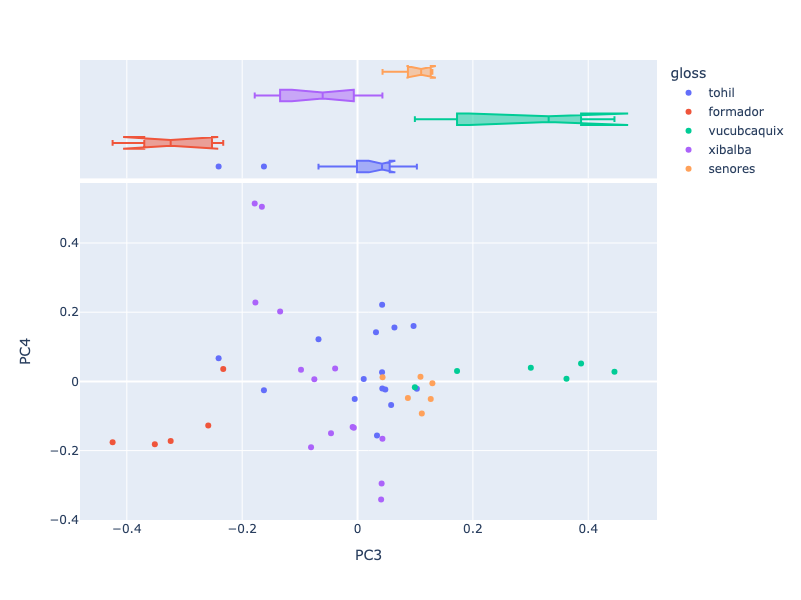

In [97]:
plot_comps(3,4)

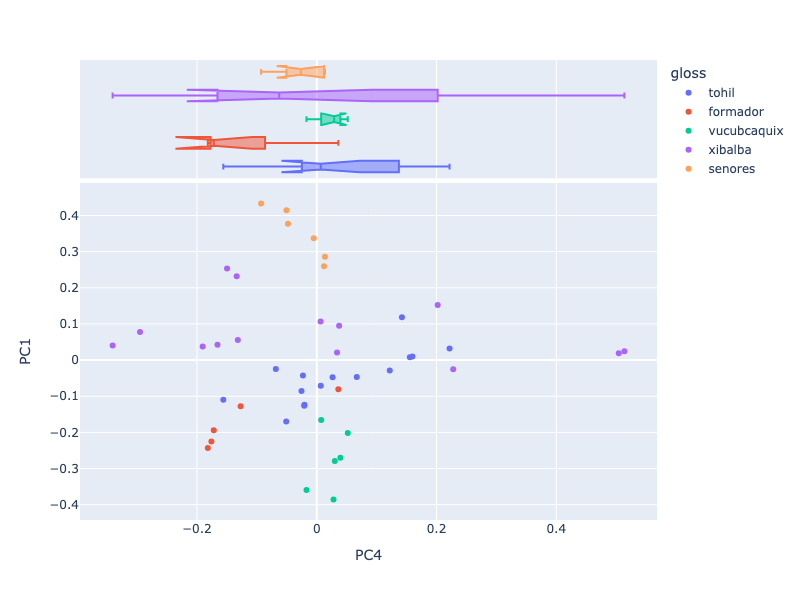

In [98]:
plot_comps(4,1)

## Get Loadings

In [99]:
LOADINGS = pd.DataFrame(comp_engine.components_.T * np.sqrt(comp_engine.explained_variance_))
LOADINGS.columns = ["PC{}".format(i) for i in LOADINGS.columns]
LOADINGS.index = TFIDF.columns
LOADINGS.index.name = 'term_str'

In [100]:
LOADINGS

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
trituradas,-0.000048,-0.001100,-0.001240,-0.002253,-0.001273,0.001044,0.000396,-0.000316,-0.000647,-0.000234
blos,0.000532,0.001569,-0.001315,0.000646,0.000032,-0.000690,0.000525,0.000183,0.001367,-0.001142
mientos,0.000532,0.001569,-0.001315,0.000646,0.000032,-0.000690,0.000525,0.000183,0.001367,-0.001142
quedar,-0.000584,0.001465,0.000697,-0.000122,-0.000673,0.000221,0.001309,0.000789,0.001096,-0.000858
derribarlas,-0.001242,-0.001982,-0.000892,0.001127,0.000335,-0.001181,-0.000202,-0.000617,-0.000301,0.000536
...,...,...,...,...,...,...,...,...,...,...
ido,-0.001583,0.001485,0.002004,0.000009,-0.000790,-0.002512,-0.001813,0.001781,-0.000103,0.000075
dirigiendo,0.001992,-0.001143,0.000616,0.000006,-0.000409,-0.002223,-0.000586,-0.000655,-0.001057,-0.000339
inquietud,0.001908,-0.000734,-0.000764,-0.001484,-0.000428,-0.001344,-0.002625,0.001479,0.000341,-0.000275


In [101]:
top_terms_sk= {}
data = []
for i in range(5):
    for j in [0, 1]:
        data.append((i, j, ' '.join(LOADINGS.sort_values(f'PC{i}', ascending=bool(j)).head(10).index.to_list())))

In [102]:
comp_strs = pd.DataFrame(data)
comp_strs.columns =  ['pc', 'pole', 'gloss']
comp_strs = comp_strs.set_index(['pc', 'pole'])

In [103]:
comp_strs.unstack()

gloss  \
pole                                                  0   
pc                                                        
0     tohil dios tribus balamacab balamquitze mahucu...   
1     senores generacion rey reyes casas casa izmach...   
2     tohil xibalba fuego pelota frio mensajeros avi...   
3     zipacna vucubcaquix hoyo muchachos cabracan ca...   
4     hunchouen hunbatz abuela red hermanos nuera mu...   

                                                         
pole                                                  1  
pc                                                       
0     xibalba pelota vucubcaquix muchachos zipacna h...  
1     vucubcaquix zipacna cabracan sol luna formador...  
2     vucubcaquix cielo generacion rey reyes gucumat...  
3     abuela formador creador creacion progenitores ...  
4     flores xibalba frio murcielagos senores fuego ...

In [104]:
LOADINGS

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
trituradas,-0.000048,-0.001100,-0.001240,-0.002253,-0.001273,0.001044,0.000396,-0.000316,-0.000647,-0.000234
blos,0.000532,0.001569,-0.001315,0.000646,0.000032,-0.000690,0.000525,0.000183,0.001367,-0.001142
mientos,0.000532,0.001569,-0.001315,0.000646,0.000032,-0.000690,0.000525,0.000183,0.001367,-0.001142
quedar,-0.000584,0.001465,0.000697,-0.000122,-0.000673,0.000221,0.001309,0.000789,0.001096,-0.000858
derribarlas,-0.001242,-0.001982,-0.000892,0.001127,0.000335,-0.001181,-0.000202,-0.000617,-0.000301,0.000536
...,...,...,...,...,...,...,...,...,...,...
ido,-0.001583,0.001485,0.002004,0.000009,-0.000790,-0.002512,-0.001813,0.001781,-0.000103,0.000075
dirigiendo,0.001992,-0.001143,0.000616,0.000006,-0.000409,-0.002223,-0.000586,-0.000655,-0.001057,-0.000339
inquietud,0.001908,-0.000734,-0.000764,-0.001484,-0.000428,-0.001344,-0.002625,0.001479,0.000341,-0.000275


In [105]:
def plot_loadings(x,y):
    fig = px.scatter(LOADINGS.reset_index(), 
        f"PC{x}", f"PC{y}", 
        height=600, width=700, 
        hover_name='term_str',
        text='term_str')
    fig.update_traces(textposition='top center')
    return fig.show()

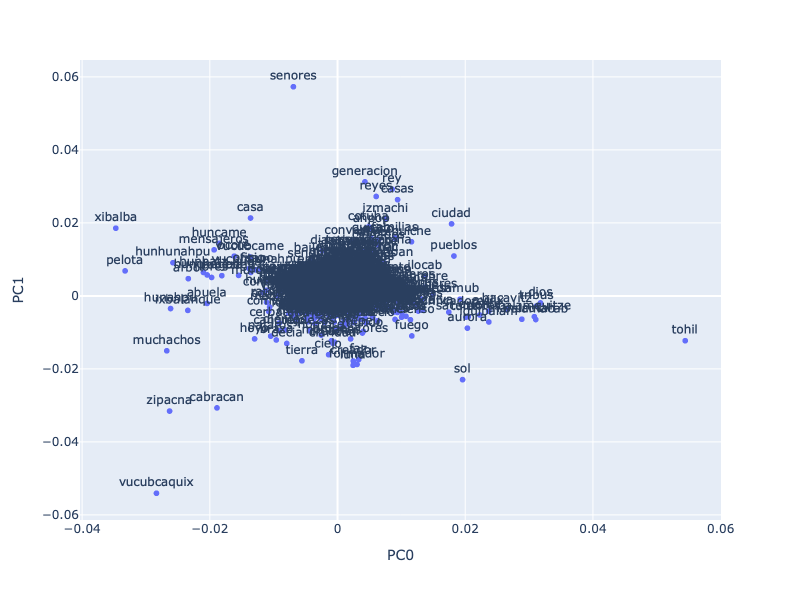

In [106]:
plot_loadings(0,1)

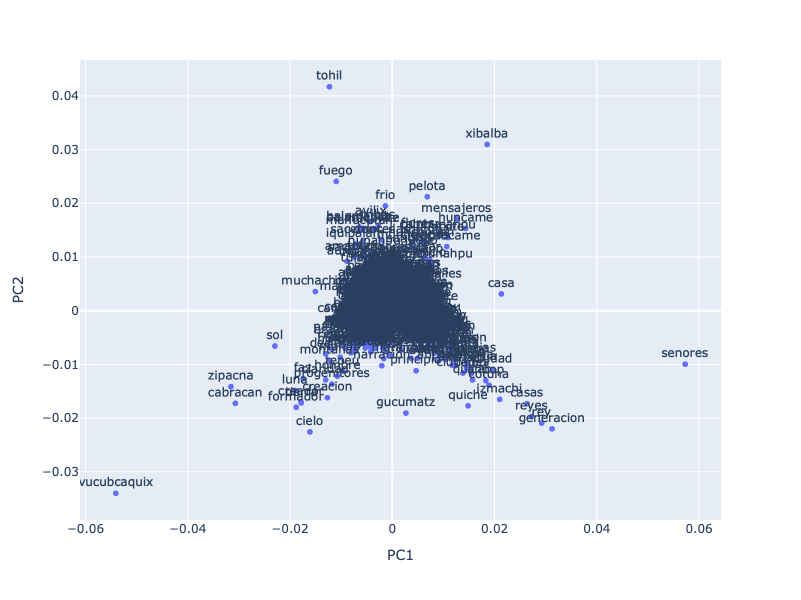

In [107]:
plot_loadings(1,2)

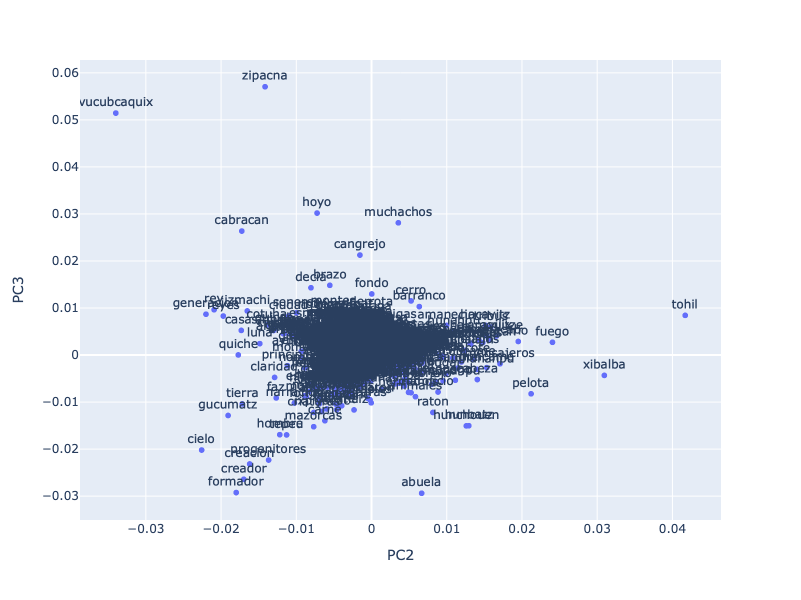

In [108]:
plot_loadings(2,3)

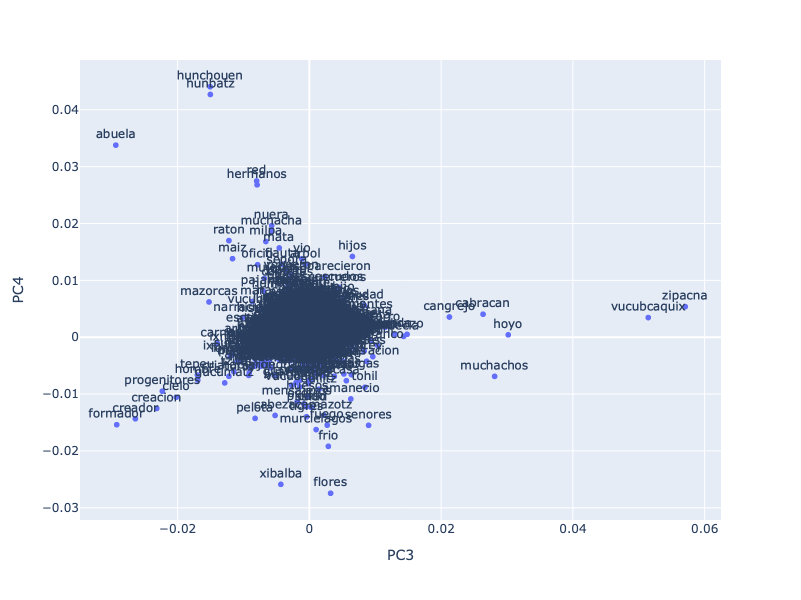

In [109]:
plot_loadings(3,4)

# Correlate Documents in Component Space

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

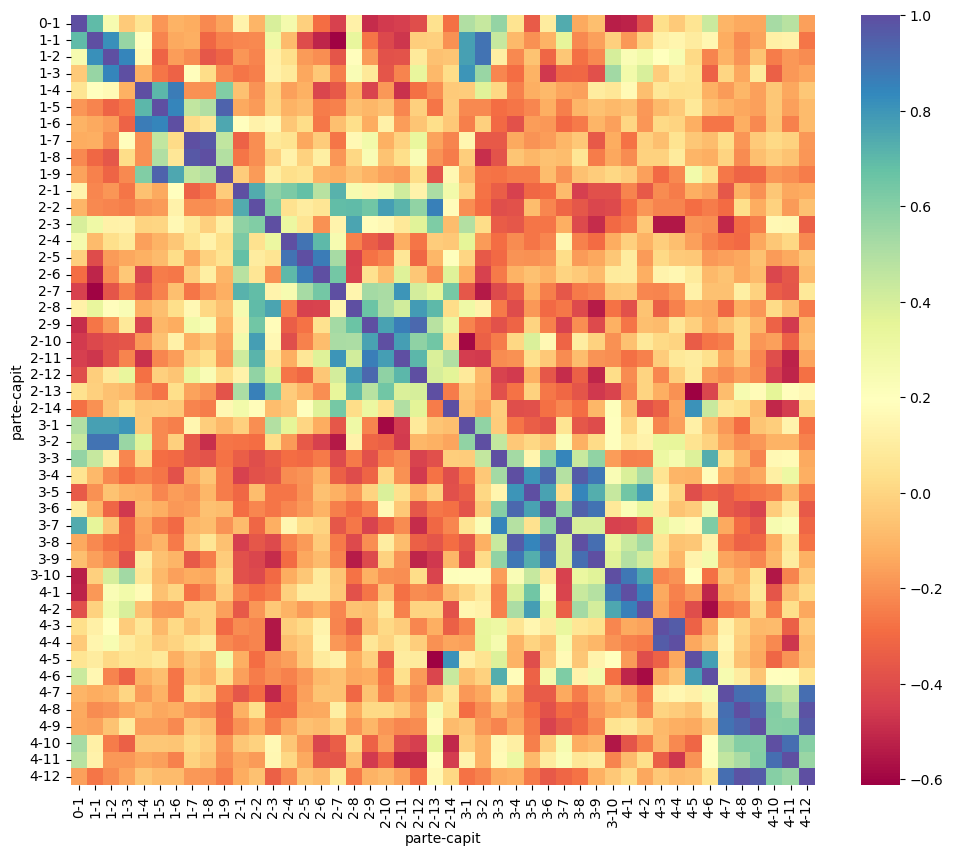

In [111]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(DCM.T.corr(), cmap='Spectral', xticklabels=True, yticklabels=True, ax=ax)
plt.show()